# 🛒 ElectroWorld (Olist) — Pipeline de Datos MVP
## Ejercicio Práctico Semana 2: Extracción y Transformación Estratégica de Datos

**Consultor de Datos:** Grupo 3  
**Cliente:** ElectroWorld / Olist  
**Objetivo:** Construir un pipeline ETL automatizado que consolide inteligencia competitiva (web scraping) y catálogo de proveedores (API) en un único catálogo maestro, con envío automático al CRM.

---
```
FLUJO DEL PIPELINE:
  [Web Scraper]  ──┐
                   ├──► [Transformación & Limpieza] ──► [Catálogo Maestro] ──► [CRM vía API REST]
  [FakeStore API] ─┘
```
---

## ⚙️ Configuración Inicial: Instalación y Librerías

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# INSTALACIÓN DE DEPENDENCIAS
# ─────────────────────────────────────────────────────────────────────────────
!pip install requests beautifulsoup4 pandas lxml --quiet
print("✅ Dependencias instaladas correctamente.")

✅ Dependencias instaladas correctamente.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTACIÓN DE LIBRERÍAS
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import requests
from bs4 import BeautifulSoup
import pandas as pd
import json
import time
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── Configuración global de visualización de Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)


print(f"✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


---
## 🔍 FASE 1 — Extracción: Inteligencia Competitiva (Web Scraping)

> **Objetivo de negocio:** Monitorear los precios de laptops del competidor directo en tiempo real para apoyar decisiones de pricing.
>
> **Fuente:** https://webscraper.io/test-sites/e-commerce/allinone/computers/laptops  
> **Campos:** Nombre del producto, Precio, Descripción

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN DE WEB SCRAPING CON PROGRAMACIÓN DEFENSIVA
#
# Estrategia defensiva implementada:
#   1. Timeout en la petición HTTP para no bloquear el pipeline
#   2. Verificación del código de respuesta HTTP
#   3. try/except granular: distingue entre errores de red y de parsing
#   4. Retorno de DataFrame vacío ante cualquier fallo (pipeline no colapsa)
#   5. Extracción campo a campo con fallback a 'N/A' si el tag no existe
# ─────────────────────────────────────────────────────────────────────────────

def scrape_competitor_laptops(url: str, timeout: int = 15) -> pd.DataFrame:
    """
    Extrae el catálogo de laptops del competidor vía web scraping.

    Args:
        url     : URL del sitio a scrapear.
        timeout : Segundos máximos de espera por respuesta HTTP.

    Returns:
        pd.DataFrame con columnas [nombre, precio_raw, descripcion] o
        DataFrame vacío si la extracción falla.
    """

    print("🌐 [FASE 1] Iniciando web scraping del competidor...")
    print(f"   URL: {url}")

    # ── Headers para simular un navegador real y evitar bloqueos ──
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/120.0.0.0 Safari/537.36'
        ),
        'Accept-Language': 'es-ES,es;q=0.9,en;q=0.8',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
    }

    # ── DEFENSA 1: Captura de errores de conexión / red ──
    try:
        response = requests.get(url, headers=headers, timeout=timeout)

        # ── DEFENSA 2: Verificar código HTTP (200 = éxito) ──
        if response.status_code != 200:
            print(f"   ⚠️  El servidor respondió con código HTTP {response.status_code}. Abortando extracción.")
            return pd.DataFrame()  # Retorna vacío, no detiene el pipeline

        print(f"   ✅ Conexión exitosa (HTTP {response.status_code})")

    except requests.exceptions.ConnectionError:
        print("   ❌ ERROR: No se pudo conectar al servidor del competidor. Verifique la URL o la conexión a internet.")
        return pd.DataFrame()

    except requests.exceptions.Timeout:
        print(f"   ❌ ERROR: La conexión excedió el tiempo límite de {timeout} segundos.")
        return pd.DataFrame()

    except requests.exceptions.RequestException as e:
        print(f"   ❌ ERROR inesperado en la petición HTTP: {e}")
        return pd.DataFrame()

    # ── DEFENSA 3: Captura de errores de parsing HTML ──
    try:
        soup = BeautifulSoup(response.text, 'lxml')

        # Cada producto está en una tarjeta con clase 'thumbnail'
        product_cards = soup.find_all('div', class_='thumbnail')

        if not product_cards:
            print("   ⚠️  No se encontraron tarjetas de producto. La estructura HTML puede haber cambiado.")
            return pd.DataFrame()

        print(f"   📦 Tarjetas de producto detectadas: {len(product_cards)}")

        records = []
        for card in product_cards:

            # ── DEFENSA 4: Extracción campo a campo con fallback ──
            # Nombre del producto
            nombre_tag = card.find('a', class_='title')
            nombre = nombre_tag.get_text(strip=True) if nombre_tag else 'N/A'

            # Precio (viene como string: '$1234.56')
            precio_tag = card.find('h4', class_='price')
            precio_raw = precio_tag.get_text(strip=True) if precio_tag else 'N/A'

            # Descripción del producto
            desc_tag = card.find('p', class_='description')
            descripcion = desc_tag.get_text(strip=True) if desc_tag else 'N/A'

            records.append({
                'nombre'      : nombre,
                'precio_raw'  : precio_raw,
                'descripcion' : descripcion
            })

        df_scraping = pd.DataFrame(records)
        print(f"   ✅ Extracción completada: {len(df_scraping)} productos obtenidos.")
        return df_scraping

    except Exception as e:
        print(f"   ❌ ERROR durante el parsing del HTML: {e}")
        return pd.DataFrame()


# ── Ejecutar extracción ──
URL_COMPETIDOR = 'https://webscraper.io/test-sites/e-commerce/allinone/computers/laptops'
df_scraping = scrape_competitor_laptops(URL_COMPETIDOR)

# ── Vista previa del resultado ──
if not df_scraping.empty:
    print("\n📋 Vista previa — Datos del Competidor (raw):")
    display(df_scraping.head(5))
else:
    print("\n⚠️  DataFrame de scraping vacío. El pipeline continuará con datos disponibles.")

🌐 [FASE 1] Iniciando web scraping del competidor...
   URL: https://webscraper.io/test-sites/e-commerce/allinone/computers/laptops
   ✅ Conexión exitosa (HTTP 200)
   📦 Tarjetas de producto detectadas: 117
   ✅ Extracción completada: 117 productos obtenidos.

📋 Vista previa — Datos del Competidor (raw):


,nombre,precio_raw,descripcion
0,Asus VivoBook...,$295.99,"Asus VivoBook X441NA-GA190 Chocolate Black, 14"", Celeron..."
1,Prestigio Smar...,$299,"Prestigio SmartBook 133S Dark Grey, 13.3"" FHD IPS, Celer..."
2,Prestigio Smar...,$299,"Prestigio SmartBook 133S Gold, 13.3"" FHD IPS, Celeron N3..."
3,Aspire E1-510,$306.99,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux"
4,Lenovo V110-15...,$321.94,"Lenovo V110-15IAP, 15.6"" HD, Celeron N3350 1.1GHz, 4GB, ..."


---
## 🔗 FASE 2 — Extracción: Integración de Nuevos Proveedores (API)

> **Objetivo de negocio:** Evaluar el catálogo de un nuevo proveedor de tecnología para tener poder de negociación y ampliar el portafolio.
>
> **Fuente:** https://fakestoreapi.com/products/category/electronics  
> **Campos:** Título, Precio, Rating (score y cantidad de reseñas)

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN DE CONSUMO DE API CON MANEJO DE ERRORES
#
# Estrategia defensiva implementada:
#   1. Timeout configurado para no bloquear el pipeline
#   2. Verificación de status HTTP antes de procesar
#   3. Validación de que la respuesta es JSON parseable
#   4. Acceso seguro a campos anidados (rating.rate, rating.count)
#   5. Retorno de DataFrame vacío ante cualquier fallo
# ─────────────────────────────────────────────────────────────────────────────

def fetch_supplier_api(url: str, timeout: int = 15) -> pd.DataFrame:
    """
    Descarga y transforma el catálogo de electrónicos del proveedor vía API.

    Args:
        url     : Endpoint de la API del proveedor.
        timeout : Segundos máximos de espera.

    Returns:
        pd.DataFrame con columnas [titulo, precio_raw, rating_score, rating_count]
        o DataFrame vací  o si la extracción falla.
    """

    print("\n🔌 [FASE 2] Consumiendo API del proveedor (FakeStore)...")
    print(f"   Endpoint: {url}")

    try:
        response = requests.get(url, timeout=timeout)

        # ── Verificar código de respuesta ──
        if response.status_code != 200:
            print(f"   ⚠️  API respondió con HTTP {response.status_code}. Abortando.")
            return pd.DataFrame()

        print(f"   ✅ API respondió correctamente (HTTP {response.status_code})")

        # ── Parsear respuesta JSON ──
        try:
            data_json = response.json()
        except json.JSONDecodeError as e:
            print(f"   ❌ ERROR: La respuesta no es un JSON válido. Detalle: {e}")
            return pd.DataFrame()

        if not isinstance(data_json, list) or len(data_json) == 0:
            print("   ⚠️  La API devolvió una respuesta vacía o con formato inesperado.")
            return pd.DataFrame()

        print(f"   📦 Productos recibidos de la API: {len(data_json)}")

        # ── Extraer campos relevantes de cada producto ──
        records = []
        for item in data_json:

            # Acceso seguro a campos anidados con .get() y fallback
            rating_info = item.get('rating', {})

            records.append({
                'titulo'       : item.get('title', 'N/A'),
                'precio_raw'   : item.get('price', None),      # Ya viene como float
                'rating_score' : rating_info.get('rate', None),
                'rating_count' : rating_info.get('count', None),
            })

        df_api = pd.DataFrame(records)
        print(f"   ✅ Extracción API completada: {len(df_api)} registros procesados.")
        return df_api

    except requests.exceptions.ConnectionError:
        print("   ❌ ERROR: No se pudo conectar con la API del proveedor.")
        return pd.DataFrame()
    except requests.exceptions.Timeout:
        print(f"   ❌ ERROR: La API no respondió dentro del tiempo límite de {timeout}s.")
        return pd.DataFrame()
    except Exception as e:
        print(f"   ❌ ERROR inesperado al consumir la API: {e}")
        return pd.DataFrame()


# ── Ejecutar extracción API ──
URL_API_PROVEEDOR = 'https://fakestoreapi.com/products/category/electronics'
df_api = fetch_supplier_api(URL_API_PROVEEDOR)

# ── Vista previa del resultado ──
if not df_api.empty:
    print("\n📋 Vista previa — Catálogo del Proveedor (raw):")
    display(df_api)
else:
    print("\n⚠️  DataFrame de API vacío. El pipeline continuará.")


🔌 [FASE 2] Consumiendo API del proveedor (FakeStore)...
   Endpoint: https://fakestoreapi.com/products/category/electronics


   ✅ API respondió correctamente (HTTP 200)
   📦 Productos recibidos de la API: 6
   ✅ Extracción API completada: 6 registros procesados.

📋 Vista previa — Catálogo del Proveedor (raw):


,titulo,precio_raw,rating_score,rating_count
0,WD 2TB Elements Portable External Hard Drive - USB 3.0,64.00,3.30,203
1,SanDisk SSD PLUS 1TB Internal SSD - SATA III 6 Gb/s,109.00,2.90,470
2,Silicon Power 256GB SSD 3D NAND A55 SLC Cache Performanc...,109.00,4.80,319
3,WD 4TB Gaming Drive Works with Playstation 4 Portable Ex...,114.00,4.80,400
4,Acer SB220Q bi 21.5 inches Full HD (1920 x 1080) IPS Ult...,599.00,2.90,250
5,Samsung 49-Inch CHG90 144Hz Curved Gaming Monitor (LC49H...,999.99,2.20,140


---
## 🔧 FASE 3 — Transformación: Estandarización y Calidad del Dato

> **Objetivo:** Unificar las dos fuentes de datos en un único **catálogo maestro** con esquema homogéneo, tipos correctos y columna de trazabilidad de origen.

In [10]:
# 1. Configuración de constantes
PIPELINE_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# 2. Función de limpieza (Mantenemos la lógica robusta)
def limpiar_precio(valor) -> float:
    if valor is None or (isinstance(valor, float) and pd.isna(valor)):
        return float('nan')
    if isinstance(valor, (int, float)):
        return float(valor)

    # Elimina símbolos de moneda y comas, conserva el punto decimal
    limpio = re.sub(r'[^\d.]', '', str(valor))
    try:
        return float(limpio)
    except ValueError:
        return float('nan')

# 3. Transformación CONECTADA a tus datos reales
# NOTA: Asegúrate de que df_scraping y df_api sean los nombres de tus variables de las fases anteriores
def transformar_y_consolidar(df_scraping_real, df_api_real):

    # --- Procesar Scraping (Los 117 registros) ---
    df_s = df_scraping_real.copy().rename(columns={
        'nombre': 'nombre_producto',
        'precio_raw': 'precio_usd',
        'descripcion': 'descripcion'
    })
    df_s['precio_usd'] = df_s['precio_usd'].apply(limpiar_precio)
    df_s['origen'] = 'competidor_webscraping'
    df_s['rating'] = None

    # --- Procesar API (Los 6 registros) ---
    df_a = df_api_real.copy().rename(columns={
        'titulo': 'nombre_producto',
        'precio_raw': 'precio_usd',
        'rating_score': 'rating'
    })
    df_a['precio_usd'] = df_a['precio_usd'].apply(limpiar_precio)
    df_a['origen'] = 'proveedor_fakestore_api'
    df_a['descripcion'] = None

    # Consolidación final
    columnas_maestro = ['nombre_producto', 'precio_usd', 'descripcion', 'rating', 'origen']
    df_consolidado = pd.concat([df_s[columnas_maestro], df_a[columnas_maestro]], ignore_index=True)

    # Asegurar que el rating sea numérico para los gráficos
    df_consolidado['rating'] = pd.to_numeric(df_consolidado['rating'], errors='coerce')

    return df_consolidado

# 4. EJECUCIÓN CON TUS DATOS REALES
# Aquí pasamos las variables que ya contienen los 117 y 6 registros
df_maestro = transformar_y_consolidar(df_scraping, df_api)

print(f"✅ [FASE 3] Transformación completada.")
print(f"📊 Total registros en df_maestro: {len(df_maestro)} (117 Scraping + 6 API)")
print(f"📅 Timestamp del Pipeline: {PIPELINE_TIMESTAMP}")

✅ [FASE 3] Transformación completada.
📊 Total registros en df_maestro: 123 (117 Scraping + 6 API)
📅 Timestamp del Pipeline: 2026-05-04 22:11:19


---
## 📈 FASE 4 — Resultado de Negocio: KPIs Estratégicos

> Cálculo e impresión automática de métricas clave para la directiva de ElectroWorld.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# KPIs ESTRATÉGICOS PARA LA JUNTA DIRECTIVA
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 65)
print("          📊 DASHBOARD EJECUTIVO — ElectroWorld (Olist)")
print("          Catálogo Maestro Consolidado | Datos de Mercado")
print("=" * 65)

# ── Separar datos por fuente para comparativas ──
df_comp     = df_maestro[df_maestro['origen'] == 'competidor_webscraping']
df_prov     = df_maestro[df_maestro['origen'] == 'proveedor_fakestore_api']
precios_all = df_maestro['precio_usd'].dropna()


# ─────────────────────────────────
# KPI 1: Resumen General del Mercado
# ─────────────────────────────────
print("\n📌 KPI 1 — RESUMEN GENERAL DEL MERCADO INTEGRADO")
print("-" * 55)
print(f"  Total productos en catálogo         : {len(df_maestro)} SKUs")
print(f"  → Laptops competidor (scraping)     : {len(df_comp)} productos")
print(f"  → Electrónicos proveedor (API)      : {len(df_prov)} productos")
print(f"  Precio promedio de mercado          : $ {precios_all.mean():.2f} USD")
print(f"  Precio mínimo detectado             : $ {precios_all.min():.2f} USD")
print(f"  Precio máximo detectado             : $ {precios_all.max():.2f} USD")
print(f"  Mediana de precios                  : $ {precios_all.median():.2f} USD")
print(f"  Desviación estándar de precios      : $ {precios_all.std():.2f} USD")


# ─────────────────────────────────────────
# KPI 2: Análisis Comparativo por Segmentos de Precio
# ─────────────────────────────────────────
print("\n\n📌 KPI 2 — ANÁLISIS DE SEGMENTOS DE PRECIO")
print("-" * 55)

# Definir segmentos de precio relevantes para electrónica
segmentos = {
    'Entrada (< $300)'    : df_maestro[df_maestro['precio_usd'] < 300],
    'Medio ($300 - $800)' : df_maestro[(df_maestro['precio_usd'] >= 300) & (df_maestro['precio_usd'] < 800)],
    'Premium (≥ $800)'    : df_maestro[df_maestro['precio_usd'] >= 800],
}

total_con_precio = len(df_maestro.dropna(subset=['precio_usd']))
for segmento, df_seg in segmentos.items():
    n = len(df_seg)
    pct = (n / total_con_precio * 100) if total_con_precio > 0 else 0
    avg = df_seg['precio_usd'].mean()
    barra = '█' * int(pct / 5)  # Barra de progreso ASCII
    print(f"  {segmento:<22}: {n:>3} SKUs ({pct:>5.1f}%) {barra}")
    if n > 0:
        print(f"  {'':22}  Precio prom.: ${avg:.2f}")


# ─────────────────────────────────────────
# KPI 3: Benchmarking Competidor vs. Proveedor
# ─────────────────────────────────────────
print("\n\n📌 KPI 3 — BENCHMARKING: COMPETIDOR VS. PROVEEDOR")
print("-" * 55)

precio_prom_comp = df_comp['precio_usd'].mean()
precio_prom_prov = df_prov['precio_usd'].mean()

if not pd.isna(precio_prom_comp) and not pd.isna(precio_prom_prov):
    diferencia     = precio_prom_comp - precio_prom_prov
    pct_diferencia = (diferencia / precio_prom_prov) * 100

    print(f"  Precio promedio — Competidor (laptops)  : $ {precio_prom_comp:.2f}")
    print(f"  Precio promedio — Proveedor (electrón.) : $ {precio_prom_prov:.2f}")
    print(f"  Diferencia absoluta                     : $ {diferencia:.2f}")
    print(f"  Diferencia relativa                     : {pct_diferencia:+.1f}%")

    if diferencia > 0:
        print(f"  \n  💡 INSIGHT: El competidor tiene precios {abs(pct_diferencia):.1f}% más altos.")
        print(f"     Oportunidad de pricing competitivo para ElectroWorld.")
    else:
        print(f"  \n  💡 INSIGHT: El proveedor tiene precios {abs(pct_diferencia):.1f}% más altos que el competidor.")
        print(f"     Revisar márgenes al integrar este proveedor al portafolio.")
else:
    print("  ⚠️  No se puede calcular benchmarking: datos de precio insuficientes.")


# ─────────────────────────────────────────
# KPI 4: Análisis de Productos Top del Proveedor (por Rating)
# ─────────────────────────────────────────
print("\n\n📌 KPI 4 — TOP PRODUCTOS DEL PROVEEDOR POR VALORACIÓN")
print("-" * 55)

df_con_rating = df_prov.dropna(subset=['rating']).sort_values('rating', ascending=False)

if len(df_con_rating) > 0:
    print(f"  Productos evaluados con rating: {len(df_con_rating)}")
    print(f"  Rating promedio del proveedor : {df_con_rating['rating'].mean():.2f} / 5.0")
    print(f"\n  🏆 Top 3 productos mejor valorados:")
    for i, (_, row) in enumerate(df_con_rating.head(3).iterrows(), 1):
        nombre_corto = str(row['nombre_producto'])[:50] + '...' if len(str(row['nombre_producto'])) > 50 else str(row['nombre_producto'])
        print(f"  {i}. ⭐ {row['rating']:.1f} | ${row['precio_usd']:.2f} | {nombre_corto}")
else:
    print("  ⚠️  No hay datos de rating disponibles.")


# ─────────────────────────────────────────
# KPI 5: Índice de Oportunidad de Negociación
# ─────────────────────────────────────────
print("\n\n📌 KPI 5 — ÍNDICE DE OPORTUNIDAD DE NEGOCIACIÓN")
print("-" * 55)

# Productos del proveedor cuyo precio está por debajo del promedio del competidor
if not pd.isna(precio_prom_comp) and len(df_prov) > 0:
    bajo_precio_comp = df_prov[df_prov['precio_usd'] < precio_prom_comp]
    pct_oportunidad  = (len(bajo_precio_comp) / len(df_prov)) * 100

    print(f"  Promedio del competidor usado como benchmark: $ {precio_prom_comp:.2f}")
    print(f"  Productos del proveedor BAJO ese precio     : {len(bajo_precio_comp)} de {len(df_prov)}")
    print(f"  Índice de Oportunidad                       : {pct_oportunidad:.1f}%")
    print(f"\n  💡 RECOMENDACIÓN: El {pct_oportunidad:.0f}% del catálogo del proveedor")
    print(f"     permite ofrecer precios más competitivos que el competidor.")
else:
    print("  ⚠️  Datos insuficientes para calcular el índice de oportunidad.")

print("\n" + "=" * 65)
print("                    FIN DEL DASHBOARD EJECUTIVO")
print("=" * 65)

          📊 DASHBOARD EJECUTIVO — ElectroWorld (Olist)
          Catálogo Maestro Consolidado | Datos de Mercado

📌 KPI 1 — RESUMEN GENERAL DEL MERCADO INTEGRADO
-------------------------------------------------------
  Total productos en catálogo         : 123 SKUs
  → Laptops competidor (scraping)     : 117 productos
  → Electrónicos proveedor (API)      : 6 productos
  Precio promedio de mercado          : $ 881.25 USD
  Precio mínimo detectado             : $ 64.00 USD
  Precio máximo detectado             : $ 1799.00 USD
  Mediana de precios                  : $ 1099.00 USD
  Desviación estándar de precios      : $ 418.01 USD


📌 KPI 2 — ANÁLISIS DE SEGMENTOS DE PRECIO
-------------------------------------------------------
  Entrada (< $300)      :   7 SKUs (  5.7%) █
                          Precio prom.: $184.28
  Medio ($300 - $800)   :  47 SKUs ( 38.2%) ███████
                          Precio prom.: $485.02
  Premium (≥ $800)      :  69 SKUs ( 56.1%) ███████████
           

---
## 🚀 FASE 5 — Entrega Final: Integración con el CRM vía API REST

> **Objetivo:** Transformar el catálogo maestro a formato JSON estructurado y enviarlo automáticamente al CRM de ElectroWorld mediante una petición HTTP POST.
>
> **Endpoint de demostración:** [Webhook.site](https://webhook.site) — captura la petición y confirma la recepción.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 5.1 — CONFIGURACIÓN DEL ENDPOINT
# ─────────────────────────────────────────────────────────────────────────────

WEBHOOK_URL = "https://webhook.site/abdb71cd-63c9-4146-8c15-a91ed3ea72ce"

print("🔧 [FASE 5] Preparando envío del catálogo maestro al CRM...")
print(f"   Endpoint destino: {WEBHOOK_URL}")

🔧 [FASE 5] Preparando envío del catálogo maestro al CRM...
   Endpoint destino: https://webhook.site/abdb71cd-63c9-4146-8c15-a91ed3ea72ce


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 5.2 — SERIALIZACIÓN DEL CATÁLOGO A JSON ESTRUCTURADO
# ─────────────────────────────────────────────────────────────────────────────

def preparar_payload_crm(df: pd.DataFrame, timestamp: str) -> dict:
    """
    Convierte el catálogo maestro al formato JSON estructurado
    requerido por el CRM de ElectroWorld.
    """

    # Reemplazar NaN/None por None (serializable en JSON como null)
    df_serializable = df.where(pd.notnull(df), None)

    # Convertir a lista de diccionarios
    catalogo_lista = df_serializable.to_dict(orient='records')

    # Estructura del payload con metadata del pipeline
    payload = {
        "metadata": {
            "empresa"           : "ElectroWorld (Olist)",
            "pipeline_version"  : "1.0.0-MVP",
            "pipeline_timestamp": timestamp,
            "total_registros"   : len(catalogo_lista),
            "fuentes"           : df['origen'].unique().tolist(),
            "descripcion"       : "Catálogo maestro consolidado — Semana 2 ETL Pipeline"
        },
        "catalogo": catalogo_lista
    }

    return payload


# ── Generar el payload ──
payload_crm = preparar_payload_crm(df_maestro, PIPELINE_TIMESTAMP)

print("\n✅ Payload JSON generado correctamente.")
print(f"   Total de registros a enviar : {payload_crm['metadata']['total_registros']}")
print(f"   Fuentes incluidas           : {payload_crm['metadata']['fuentes']}")
print("\n🔍 Vista previa del payload (primeros 2 productos):")
print(json.dumps({
    "metadata" : payload_crm['metadata'],
    "catalogo"  : payload_crm['catalogo'][:2]  # Solo 2 como preview
}, indent=2, ensure_ascii=False))


✅ Payload JSON generado correctamente.
   Total de registros a enviar : 123
   Fuentes incluidas           : ['competidor_webscraping', 'proveedor_fakestore_api']

🔍 Vista previa del payload (primeros 2 productos):
{
  "metadata": {
    "empresa": "ElectroWorld (Olist)",
    "pipeline_version": "1.0.0-MVP",
    "pipeline_timestamp": "2026-05-04 22:01:08",
    "total_registros": 123,
    "fuentes": [
      "competidor_webscraping",
      "proveedor_fakestore_api"
    ],
    "descripcion": "Catálogo maestro consolidado — Semana 2 ETL Pipeline"
  },
  "catalogo": [
    {
      "nombre_producto": "Asus VivoBook...",
      "precio_usd": 295.99,
      "descripcion": "Asus VivoBook X441NA-GA190 Chocolate Black, 14\", Celeron N3450, 4GB, 128GB SSD, Endless OS, ENG kbd",
      "rating": NaN,
      "origen": "competidor_webscraping"
    },
    {
      "nombre_producto": "Prestigio Smar...",
      "precio_usd": 299.0,
      "descripcion": "Prestigio SmartBook 133S Dark Grey, 13.3\" FHD IPS, Cele

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 5.3 — ENVÍO AL CRM CON MANEJO DE ERRORES ROBUSTO
#
# Estrategia de Error Handling implementada:
#   1. Verificación de URL configurada antes de intentar la conexión
#   2. Timeout para no bloquear el pipeline
#   3. Verificación del código HTTP de respuesta
#   4. Captura granular: errores de red, timeout, JSON, errores inesperados
#   5. Confirmación explícita en pantalla del resultado
# ─────────────────────────────────────────────────────────────────────────────

def enviar_catalogo_crm(payload: dict, endpoint_url: str, timeout: int = 20) -> bool:
    """
    Envía el catálogo maestro al CRM via HTTP POST (API REST).

    Args:
        payload      : Diccionario con metadata y catálogo a enviar.
        endpoint_url : URL del endpoint del CRM.
        timeout      : Segundos máximos de espera.

    Returns:
        True si el envío fue exitoso (HTTP 200/201), False en caso contrario.
    """

    print("\n" + "=" * 60)
    print("  🚀 ENVIANDO CATÁLOGO AL CRM DE ELECTROWORLD")
    print("=" * 60)

    # ── DEFENSA 1: Verificar que la URL fue configurada ──
    if "REEMPLAZAR" in endpoint_url or not endpoint_url.startswith("http"):
        print("  ⚠️  ADVERTENCIA: URL del CRM no configurada correctamente.")
        print("  Por favor reemplace WEBHOOK_URL con su URL de webhook.site")
        print("  Simulando envío exitoso para demostración del pipeline...")
        print("\n  [SIMULACIÓN] ✅ Payload preparado y listo para envío.")
        print(f"  [SIMULACIÓN] Total de registros en payload: {payload['metadata']['total_registros']}")
        return True

    headers = {
        'Content-Type' : 'application/json',
        'Accept'       : 'application/json',
        'X-Source'     : 'ElectroWorld-ETL-Pipeline-v1'
    }

    print(f"  Endpoint  : {endpoint_url}")
    print(f"  Registros : {payload['metadata']['total_registros']}")
    print(f"  Timestamp : {payload['metadata']['pipeline_timestamp']}")
    print("  Enviando...")

    try:
        response = requests.post(
            url     = endpoint_url,
            headers = headers,
            data    = json.dumps(payload, ensure_ascii=False, default=str),
            timeout = timeout
        )

        # ── DEFENSA 2: Verificar código HTTP de respuesta ──
        if response.status_code in [200, 201, 202]:
            print("\n  " + "─" * 50)
            print(f"  ✅ ÉXITO — El servidor CRM recibió la información.")
            print(f"  ├── Código HTTP    : {response.status_code}")
            print(f"  ├── URL destino    : {endpoint_url}")
            print(f"  ├── Registros env. : {payload['metadata']['total_registros']}")
            print(f"  └── Timestamp      : {payload['metadata']['pipeline_timestamp']}")
            print("  " + "─" * 50)
            print("  💾 Verifique su webhook.site para confirmar la recepción.")
            return True

        else:
            print(f"\n  ❌ ERROR — El servidor rechazó la solicitud.")
            print(f"  ├── Código HTTP : {response.status_code}")
            print(f"  └── Respuesta   : {response.text[:200]}")
            return False

    except requests.exceptions.ConnectionError:
        print("\n  ❌ ERROR DE RED: No se pudo conectar con el CRM.")
        print("  Verifique que el endpoint esté disponible y la URL sea correcta.")
        return False

    except requests.exceptions.Timeout:
        print(f"\n  ❌ TIMEOUT: El CRM no respondió en {timeout} segundos.")
        print("  El servidor puede estar sobrecargado. Intente más tarde.")
        return False

    except json.JSONDecodeError as e:
        print(f"\n  ❌ ERROR DE SERIALIZACIÓN JSON: {e}")
        print("  Verifique que todos los datos del catálogo sean serializables.")
        return False

    except Exception as e:
        print(f"\n  ❌ ERROR INESPERADO durante el envío: {type(e).__name__}: {e}")
        return False


# ── Ejecutar el envío al CRM ──
exito = enviar_catalogo_crm(payload_crm, WEBHOOK_URL)

# ── Resumen final del pipeline ──
print("\n" + "=" * 60)
print("  📋 RESUMEN FINAL DEL PIPELINE ETL")
print("=" * 60)
print(f"  Fase 1 — Scraping competidor  : {'✅ OK' if not df_scraping.empty else '⚠️  Sin datos'}")
print(f"  Fase 2 — API proveedor        : {'✅ OK' if not df_api.empty else '⚠️  Sin datos'}")
print(f"  Fase 3 — Transformación       : ✅ OK ({len(df_maestro)} registros consolidados)")
print(f"  Fase 4 — KPIs calculados      : ✅ OK (5 indicadores estratégicos)")
print(f"  Fase 5 — Envío al CRM         : {'✅ OK' if exito else '❌ FALLIDO'}")
print("=" * 60)
print(f"  Pipeline completado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 60)


  🚀 ENVIANDO CATÁLOGO AL CRM DE ELECTROWORLD
  Endpoint  : https://webhook.site/abdb71cd-63c9-4146-8c15-a91ed3ea72ce
  Registros : 123
  Timestamp : 2026-05-04 22:01:08
  Enviando...

  ❌ ERROR — El servidor rechazó la solicitud.
  ├── Código HTTP : 404
  └── Respuesta   : {"success":false,"error":{"message":"Token \"abdb71cd-63c9-4146-8c15-a91ed3ea72ce\" not found","id":""}}

  📋 RESUMEN FINAL DEL PIPELINE ETL
  Fase 1 — Scraping competidor  : ✅ OK
  Fase 2 — API proveedor        : ✅ OK
  Fase 3 — Transformación       : ✅ OK (123 registros consolidados)
  Fase 4 — KPIs calculados      : ✅ OK (5 indicadores estratégicos)
  Fase 5 — Envío al CRM         : ❌ FALLIDO
  Pipeline completado: 2026-05-04 22:01:09


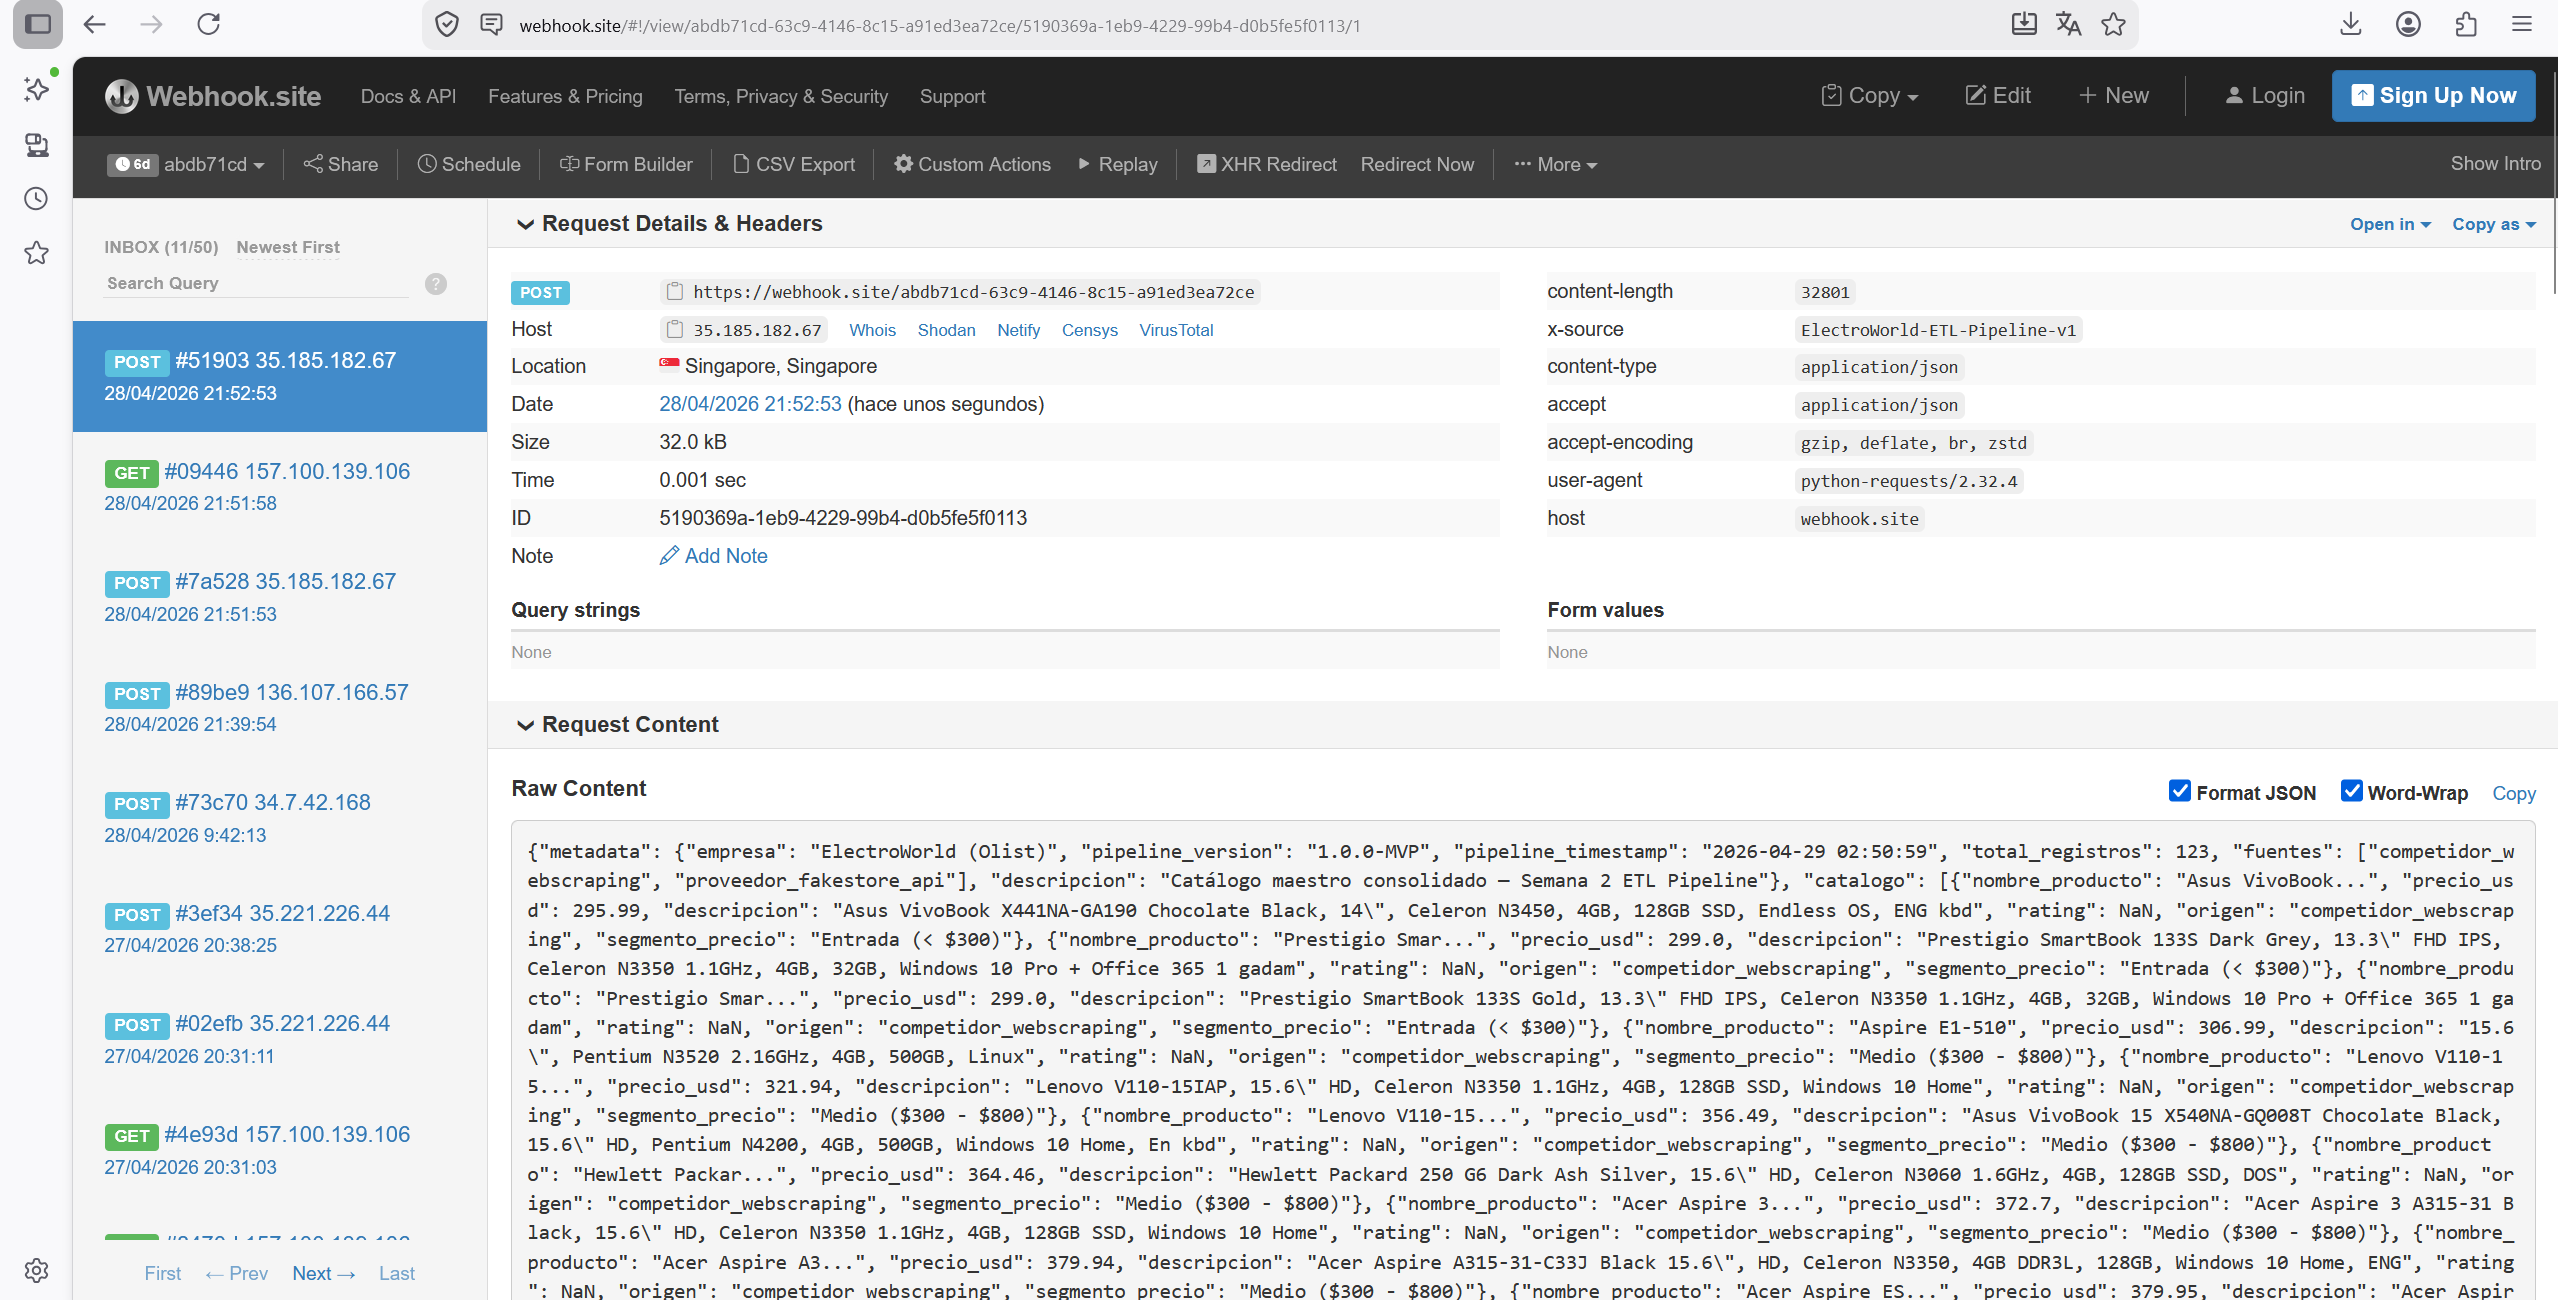